# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0f2027, #203a43, #2c5364); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>4.1 Load Data & Tuned Parameters</b></div>

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay, precision_recall_curve
)


In [33]:
X_train,X_test,y_train,y_test = joblib.load("../models/train_test_split.pkl")
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

best_params = joblib.load("../models/xgb_best_params.pkl")
print("Best parameters:", best_params)

X_train shape: (72836, 28)
X_test shape: (18210, 28)
y_train shape: (72836,)
y_test shape: (18210,)
Best parameters: {'n_estimators': 943, 'max_depth': 5, 'learning_rate': 0.046590058103669396, 'subsample': 0.9648549173887546, 'colsample_bytree': 0.9957609029778385, 'min_child_weight': 9, 'reg_lambda': 1.1126684305635504, 'reg_alpha': 0.16981486696331743}


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0f2027, #203a43, #2c5364); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>4.2 Train Final Model</b></div>

In [34]:
pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_best = XGBClassifier(
    **best_params,
    scale_pos_weight=pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb_best.fit(X_train, y_train)
print("Model trained with best parameters.")

Model trained with best parameters.


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0f2027, #203a43, #2c5364); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>4.3 Model Evaluation</b></div>

In [35]:
y_proba = xgb_best.predict_proba(X_test)[:,1]
y_pred = xgb_best.predict(X_test)
auc = roc_auc_score(y_test, y_proba)
print(f"ROC AUC Score: {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names= ['No Default', 'Default']))

ROC AUC Score: 0.9572

              precision    recall  f1-score   support

  No Default       0.96      0.94      0.95     15151
     Default       0.75      0.83      0.79      3059

    accuracy                           0.93     18210
   macro avg       0.86      0.89      0.87     18210
weighted avg       0.93      0.93      0.93     18210



The model correctly identifies **83% of real defaulters** , the most 
important metric in credit risk, since approving a loan to someone who 
defaults costs far more than turning away a safe applicant.

Precision of 75% means 1 in 4 flagged defaulters is actually safe , 
an acceptable tradeoff for a lending scenario where caution is preferred.

## Confusion Matrix

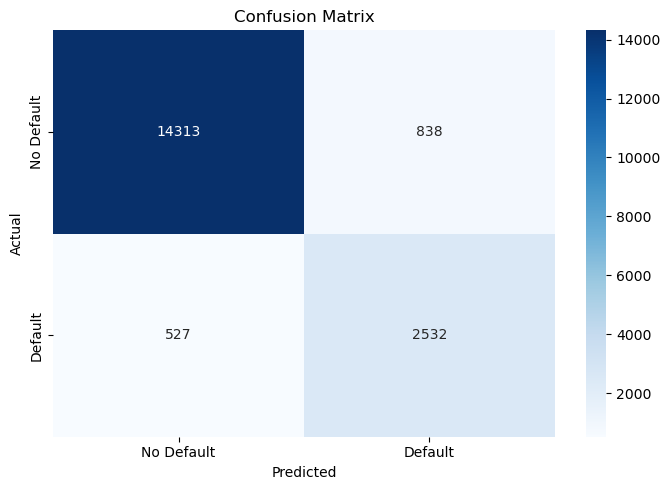

In [36]:
# Confusion Matrix
cm =  confusion_matrix(y_test,y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## ROC Curve

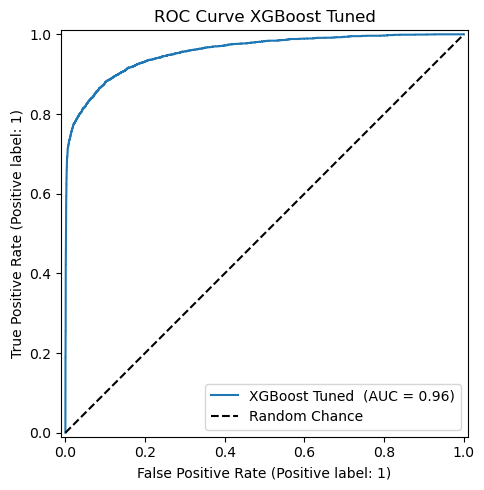

In [42]:
plt.figure(figsize=(7,5))
RocCurveDisplay.from_predictions(
    y_test,y_proba, name = f"XGBoost Tuned ",
    ax = plt.gca()
)
plt.plot([0,1],[0,1],'k--', label='Random Chance')
plt.title('ROC Curve XGBoost Tuned')
plt.legend()
plt.tight_layout()
plt.show()

## Threshold Analysis

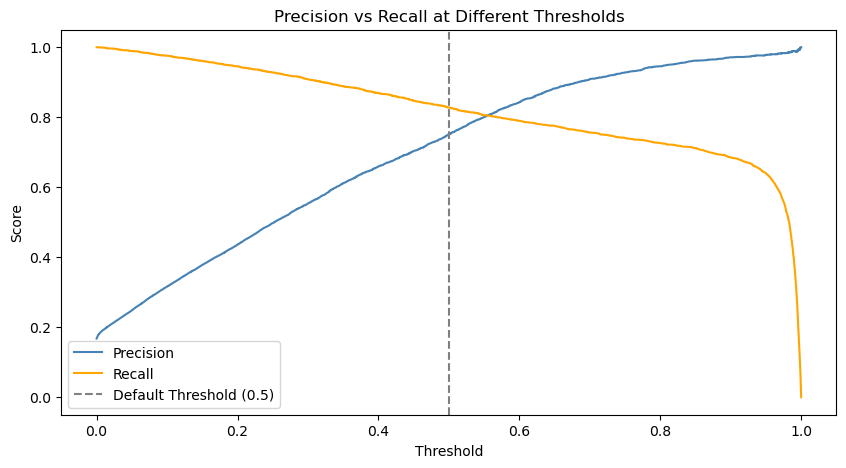

In [38]:
precision , recall , thresholds = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(10,5))
plt.plot(thresholds, precision[:-1], label = 'Precision', color = 'steelblue')
plt.plot(thresholds , recall[:-1],label = 'Recall', color = 'orange')
plt.axvline(x=0.5, color='grey', linestyle='--', label='Default Threshold (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at Different Thresholds')
plt.legend()
plt.show()


## Threshold Analysis Insight :

At the default threshold of 0.5, the model catches **83% of real defaulters** 
while maintaining **75% precision** . Meaning most of its default predictions 
are correct.

The chart shows a classic tradeoff: lowering the threshold catches more 
defaulters but also flags more safe applicants as risky. Raising it does 
the opposite which means, fewer false alarms but more defaulters slip through.

For a lending business, missing a real defaulter is more costly than 
wrongly rejecting a safe applicant. 

The current threshold of 0.5 gives a good balance for a general-purpose 
model, and can be adjusted based on how much risk the business is 
willing to take.

## Full Model Journey

| Model | CV Mean AUC | Handles Imbalance |
|---|---|---|
| Logistic Regression | 0.8951 | ✅ class_weight=balanced |
| Random Forest | 0.9390 | ✅ class_weight=balanced |
| XGBoost Baseline | 0.9525 | ✅ scale_pos_weight |
| ⭐ XGBoost Tuned | **0.9572** | ✅ scale_pos_weight |


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0f2027, #203a43, #2c5364); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>4.4 Feature Importance</b></div>

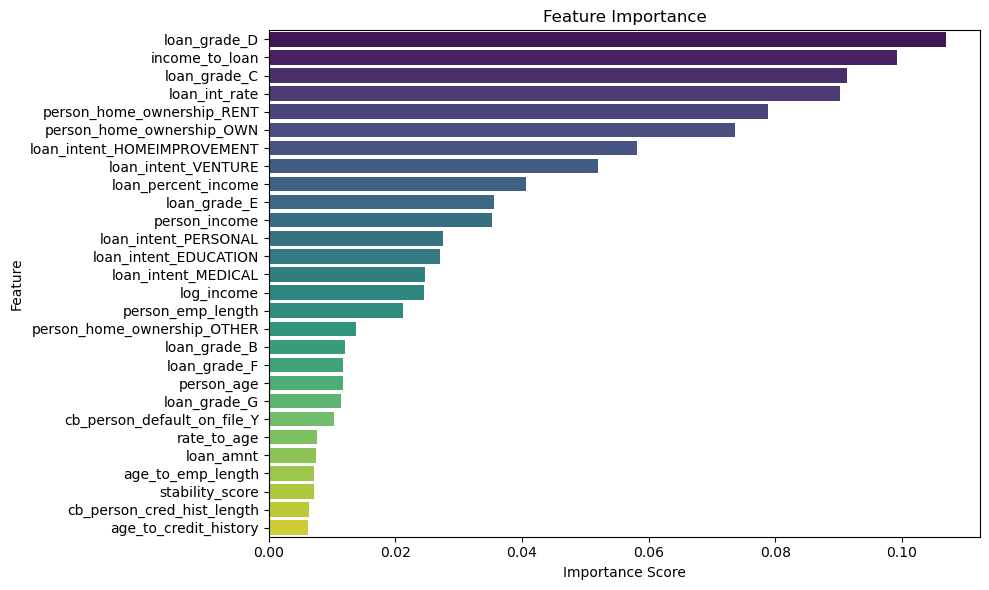

Top 10 Most Important Features:


,Feature,Importance
0,loan_grade_D,0.107017
1,income_to_loan,0.099289
2,loan_grade_C,0.091375
3,loan_int_rate,0.090199
4,person_home_ownership_RENT,0.078812
5,person_home_ownership_OWN,0.073606
6,loan_intent_HOMEIMPROVEMENT,0.058168
7,loan_intent_VENTURE,0.052071
8,loan_percent_income,0.040625
9,loan_grade_E,0.035662


In [39]:
feat_imp_df = pd.DataFrame({
    'Feature' : X_train.columns,
    'Importance' : xgb_best.feature_importances_

}).sort_values(by='Importance', ascending= False).reset_index(drop=True)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data= feat_imp_df,palette='viridis')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


print("Top 10 Most Important Features:")
display(feat_imp_df.head(10))


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0f2027, #203a43, #2c5364); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>4.5 Save Final Model</b></div>

In [40]:
joblib.dump(xgb_best, "../models/best_model.pkl")
print("Best model saved to '../models/best_model.pkl'")

Best model saved to '../models/best_model.pkl'
